# ED408 — Statistical Machine Learning II Lab (Module I)
### Dataset: *Berkeley Segmentation Dataset* (BSDS500)

All seven labs are performed on a single **image dataset**: the Berkeley Segmentation Dataset (500 natural images, each hand-segmented by ~5 human annotators). We cast it as a tabular ML problem: **boundary vs non-boundary pixel classification** — given 17 hand-crafted local features of a pixel, predict whether humans marked an object boundary there.

Why this is *not* a toy problem:
- **Label construction is non-trivial**: humans disagree, so a pixel is labelled *boundary* only when ≥2 annotators agree (within 1 px), *non-boundary* only when *no* annotator marked within 2 px; ambiguous pixels are excluded — a deliberate label-noise control.
- **Class imbalance**: true boundary prevalence in an image is only ~2–5%; we subsample negatives to a 73/27 ratio to keep training tractable while preserving the imbalance story.
- **Heavy-tailed features**: gradient magnitudes and Laplacian responses have extreme right tails (edges of high-contrast objects), which breaks Gaussian assumptions and naive outlier rules.
- **Correlated multi-scale features**: the same physical edge fires many filters at once — relevant for PCA, Naive Bayes independence, and tree feature importances.
- **Leakage-safe evaluation**: train and test pixels come from **disjoint images** (BSDS's own train/test folders) — the image analogue of avoiding temporal leakage.

**Features (per pixel):** CIELAB colour (L, a, b); Gaussian gradient magnitude at σ∈{1,2,4}; local standard deviation at σ∈{1,2,4}; |Laplacian of Gaussian| at σ∈{1,2}; oriented derivative energy at 0°/45°/90°/135° (σ=2); the two structure-tensor eigenvalues (edge/corner energy).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


,count,mean,std,min,25%,50%,75%,max
L,48000.0,45.84,23.04,0.00,28.30,44.33,61.21,100.00
a,48000.0,-2.83,11.00,-52.91,-8.22,-3.17,1.04,61.83
b,48000.0,11.23,16.52,-52.84,0.51,10.87,21.33,85.89
gradmag_s1,48000.0,3.19,3.98,0.00,0.58,1.73,4.16,35.05
gradmag_s2,48000.0,1.89,2.20,0.00,0.39,1.08,2.53,17.91
gradmag_s4,48000.0,1.10,1.19,0.00,0.26,0.67,1.51,8.94
localstd_s1,48000.0,5.12,5.26,0.00,1.24,3.40,7.20,40.42
localstd_s2,48000.0,7.02,6.27,0.00,2.11,5.31,10.13,43.03
localstd_s4,48000.0,8.94,6.88,0.00,3.46,7.51,12.91,44.05
abslap_s1,48000.0,2.59,3.45,0.00,0.33,1.24,3.46,36.60


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 1 — k-Nearest Neighbours **from scratch**

A fully vectorised implementation (no `sklearn.neighbors`). kNN is O(n·m) per query, so we work on a stratified subsample and study:
1. the effect of **feature scaling** (L runs 0–100 while a/b run ±60 and gradients 0–40 — unscaled distances are dominated by whichever filter happens to have the largest numeric range),
2. **k-selection** via a validation curve,
3. **distance-weighted voting** vs majority voting.

In [2]:
class KNNScratch:
    """Vectorised kNN with Euclidean distance and optional distance weighting."""
    def __init__(self, k=5, weighted=False):
        self.k, self.weighted = k, weighted

    def fit(self, X, y):
        self.X, self.y = np.asarray(X, float), np.asarray(y)
        return self

    def _dist(self, Q):
        # (q - x)^2 = q^2 - 2qx + x^2  -> full pairwise matrix without loops
        d2 = (Q**2).sum(1)[:, None] - 2 * Q @ self.X.T + (self.X**2).sum(1)[None, :]
        return np.sqrt(np.maximum(d2, 0))

    def predict_proba(self, Q, batch=1000):
        Q = np.asarray(Q, float)
        out = np.empty(len(Q))
        for s in range(0, len(Q), batch):
            D = self._dist(Q[s:s+batch])
            idx = np.argpartition(D, self.k, axis=1)[:, :self.k]
            labels = self.y[idx]
            if self.weighted:
                w = 1.0 / (np.take_along_axis(D, idx, 1) + 1e-9)
                out[s:s+batch] = (w * labels).sum(1) / w.sum(1)
            else:
                out[s:s+batch] = labels.mean(1)
        return out

    def predict(self, Q):
        return (self.predict_proba(Q) >= 0.5).astype(int)

def stratified_subsample(X, y, n, rng):
    idx = np.hstack([rng.choice(np.where(y==c)[0], int(n*(y==c).mean()), replace=False) for c in (0,1)])
    rng.shuffle(idx)
    return X[idx], y[idx]

Xs_tr, ys_tr = stratified_subsample(X_tr, y_tr, 6000, RNG)
Xs_te, ys_te = stratified_subsample(X_te, y_te, 2000, RNG)

# standardise using TRAIN statistics only
mu, sd = Xs_tr.mean(0), Xs_tr.std(0) + 1e-12
Z_tr, Z_te = (Xs_tr - mu)/sd, (Xs_te - mu)/sd

from sklearn.metrics import f1_score, accuracy_score
print("Unscaled  acc:", round(accuracy_score(ys_te, KNNScratch(15).fit(Xs_tr, ys_tr).predict(Xs_te)), 4))
print("Scaled    acc:", round(accuracy_score(ys_te, KNNScratch(15).fit(Z_tr,  ys_tr).predict(Z_te)), 4))

Unscaled  acc: 0.7834
Scaled    acc: 0.8089


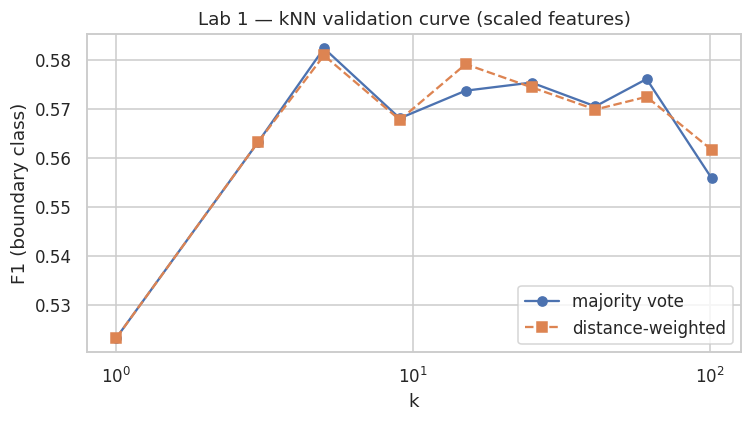

Best k=5: acc=0.7964, F1=0.5808


In [3]:
ks = [1, 3, 5, 9, 15, 25, 41, 61, 101]
res = {"plain": [], "weighted": []}
for k in ks:
    res["plain"].append(f1_score(ys_te, KNNScratch(k).fit(Z_tr, ys_tr).predict(Z_te)))
    res["weighted"].append(f1_score(ys_te, KNNScratch(k, weighted=True).fit(Z_tr, ys_tr).predict(Z_te)))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ks, res["plain"], "o-", label="majority vote")
ax.plot(ks, res["weighted"], "s--", label="distance-weighted")
ax.set(xlabel="k", ylabel="F1 (boundary class)", title="Lab 1 — kNN validation curve (scaled features)")
ax.set_xscale("log"); ax.legend(); plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(res["weighted"]))]
best = KNNScratch(best_k, weighted=True).fit(Z_tr, ys_tr)
pred = best.predict(Z_te)
print(f"Best k={best_k}: acc={accuracy_score(ys_te, pred):.4f}, F1={f1_score(ys_te, pred):.4f}")

**Observations.** Scaling changes the metric geometry: without it the L channel and large-σ filters dominate the distance. Boundary pixels *are* locally structured (an edge looks like an edge), so kNN performs far better here than on diffuse tabular problems — but it still misses low-contrast boundaries that humans mark from object knowledge rather than local evidence.

---
# Lab 2 — Decision Tree (scikit-learn) with pruning + visualisation

A fully grown tree memorises tens of thousands of pixels; we use **cost-complexity pruning** (`ccp_alpha`) chosen on a validation split, then visualise the pruned tree.

best ccp_alpha=1.76e-04, leaves=127, depth=13
test acc=0.7627, test F1=0.6182


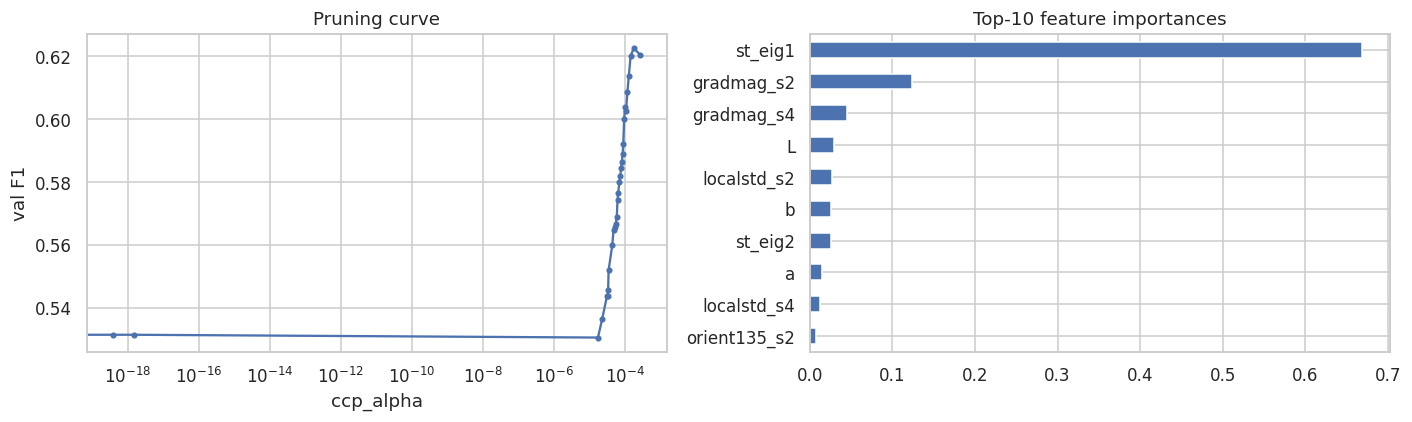

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split as tts

X_fit, X_val, y_fit, y_val = tts(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=0)

path = DecisionTreeClassifier(random_state=0, class_weight="balanced").cost_complexity_pruning_path(X_fit, y_fit)
alphas = np.unique(np.clip(path.ccp_alphas, 0, None))[::max(1, len(path.ccp_alphas)//40)]

val_f1 = []
for a in alphas:
    t = DecisionTreeClassifier(random_state=0, class_weight="balanced", ccp_alpha=a).fit(X_fit, y_fit)
    val_f1.append(f1_score(y_val, t.predict(X_val)))

best_a = alphas[int(np.argmax(val_f1))]
tree = DecisionTreeClassifier(random_state=0, class_weight="balanced", ccp_alpha=best_a).fit(X_tr, y_tr)
print(f"best ccp_alpha={best_a:.2e}, leaves={tree.get_n_leaves()}, depth={tree.get_depth()}")
print(f"test acc={accuracy_score(y_te, tree.predict(X_te)):.4f}, test F1={f1_score(y_te, tree.predict(X_te)):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(alphas, val_f1, ".-"); ax[0].set(xscale="log", xlabel="ccp_alpha", ylabel="val F1", title="Pruning curve")
imp = pd.Series(tree.feature_importances_, index=features).nlargest(10)
imp.plot.barh(ax=ax[1], title="Top-10 feature importances"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

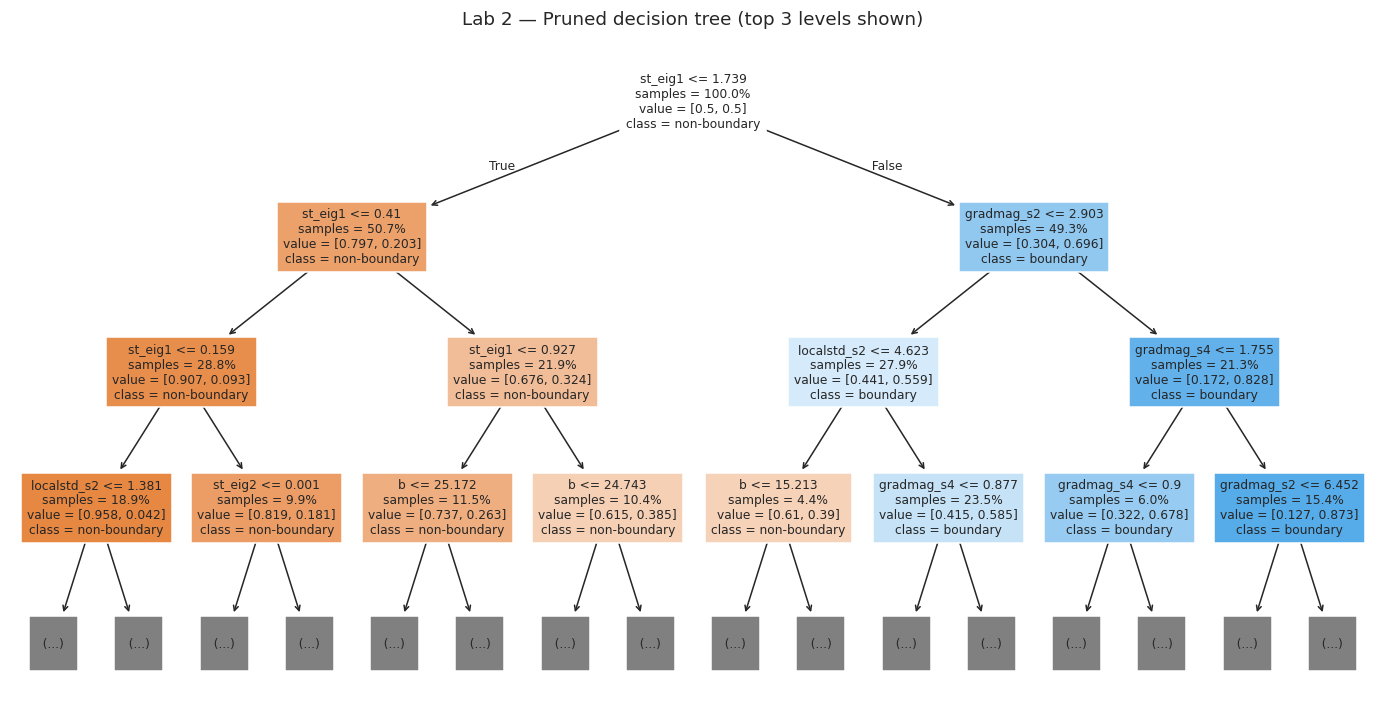

In [5]:
fig = plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=features, class_names=["non-boundary","boundary"],
          filled=True, max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title("Lab 2 — Pruned decision tree (top 3 levels shown)")
plt.show()

**Observations.** The tree's early splits use gradient/contrast features — a decision-tree rediscovery of classical edge detection: threshold the gradient. The interesting part is what pruning removes: deep leaves that memorised individual textured regions (grass, water) where filters fire strongly but humans draw no boundary.

---
# Lab 3 — Naive Bayes (boundary vs non-boundary in place of spam vs ham)

The syllabus item is spam/ham; we keep the *detection* methodology: boundary pixels are the "spam" to be flagged. Two twists that make it non-trivial:
1. **Gaussian NB assumptions are violated** — gradient/Laplacian features have extreme right tails. We compare raw vs `signed-log` transformed features.
2. **Testing the naive independence assumption itself**: the same physical edge fires *all* the gradient filters at once, so features are strongly class-conditionally correlated. We compare Naive Bayes against **QDA** — the same Gaussian likelihood but with a full class covariance matrix, i.e. NB with the independence assumption removed. The NB-vs-QDA gap is the *price of "naive"* on deliberately redundant features.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, roc_auc_score

def slog(x):  # signed log1p — a/b channels can be negative
    return np.sign(x) * np.log1p(np.abs(x))

gnb_raw = GaussianNB().fit(X_tr, y_tr)
gnb_log = GaussianNB().fit(slog(X_tr), y_tr)
qda_log = QuadraticDiscriminantAnalysis(reg_param=1e-3).fit(slog(X_tr), y_tr)

print("GaussianNB raw : AUC =", round(roc_auc_score(y_te, gnb_raw.predict_proba(X_te)[:,1]), 4))
print("GaussianNB slog: AUC =", round(roc_auc_score(y_te, gnb_log.predict_proba(slog(X_te))[:,1]), 4))
print("QDA slog (independence assumption removed): AUC =",
      round(roc_auc_score(y_te, qda_log.predict_proba(slog(X_te))[:,1]), 4))
print()
print(classification_report(y_te, gnb_log.predict(slog(X_te)), target_names=["non-boundary","boundary"]))

GaussianNB raw : AUC = 0.8191
GaussianNB slog: AUC = 0.8246
QDA slog (independence assumption removed): AUC = 0.832

              precision    recall  f1-score   support

non-boundary       0.87      0.81      0.84     13200
    boundary       0.56      0.67      0.61      4800

    accuracy                           0.77     18000
   macro avg       0.71      0.74      0.72     18000
weighted avg       0.79      0.77      0.78     18000



**Observations.** The log transform repairs the marginal likelihoods (heavy tails → nearly Gaussian). The QDA comparison then isolates the cost of the independence assumption on features that are *engineered to be redundant* — multi-scale filters of the same edge. Whatever gap appears between NB and QDA is exactly the price of "naive".

---
# Lab 4 — Logistic Regression **from scratch** (gradient descent)

Implemented with: numerically-stable sigmoid/loss, **L2 regularisation**, full-batch gradient descent, and **class-weighted loss** to counter the 73/27 imbalance. Verified against scikit-learn.

scratch (plain)      AUC=0.8357  F1=0.5604
scratch (balanced)   AUC=0.8362  F1=0.6230
sklearn (balanced)   AUC=0.8385  F1=0.6246


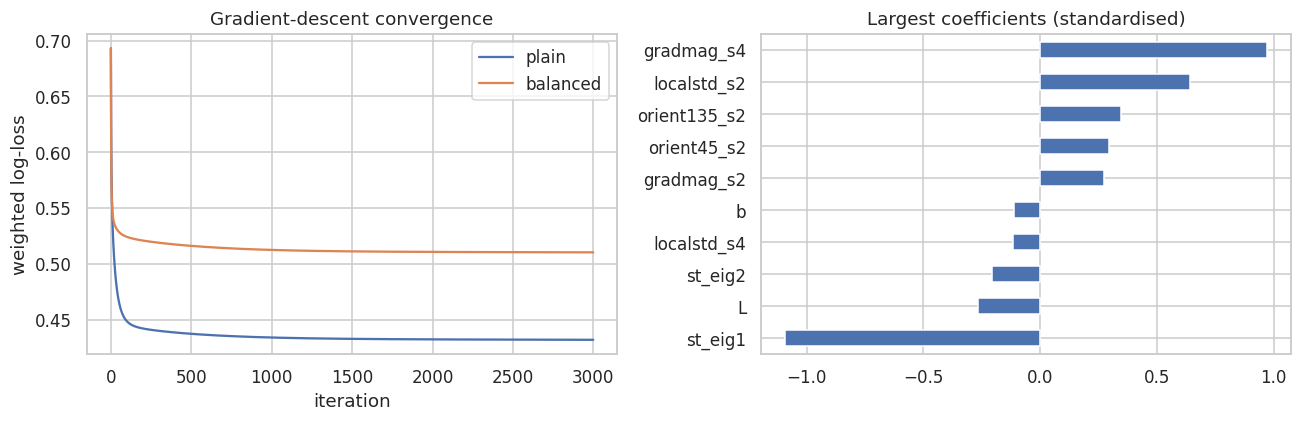

In [7]:
class LogRegGD:
    def __init__(self, lr=0.1, n_iter=3000, l2=1e-3, class_weight=None):
        self.lr, self.n_iter, self.l2, self.class_weight = lr, n_iter, l2, class_weight

    @staticmethod
    def _sigmoid(z):
        out = np.empty_like(z)
        pos = z >= 0
        out[pos] = 1 / (1 + np.exp(-z[pos]))
        e = np.exp(z[~pos]); out[~pos] = e / (1 + e)
        return out

    def fit(self, X, y):
        n, m = X.shape
        self.w, self.b = np.zeros(m), 0.0
        w_i = np.ones(n)
        if self.class_weight == "balanced":
            w_i = np.where(y==1, n/(2*y.sum()), n/(2*(n-y.sum())))
        self.loss_ = []
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            p = self._sigmoid(z)
            # stable log-loss: log(1+e^{-|z|}) + max(z,0) - z*y
            ll = (w_i * (np.log1p(np.exp(-np.abs(z))) + np.maximum(z,0) - z*y)).mean()
            self.loss_.append(ll + 0.5*self.l2*(self.w @ self.w)/n)
            g = w_i * (p - y)
            self.w -= self.lr * (X.T @ g / n + self.l2 * self.w / n)
            self.b -= self.lr * g.mean()
        return self

    def predict_proba(self, X): return self._sigmoid(X @ self.w + self.b)
    def predict(self, X, t=0.5): return (self.predict_proba(X) >= t).astype(int)

mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-12
Zt, Ze = (X_tr-mu)/sd, (X_te-mu)/sd

lr_plain = LogRegGD().fit(Zt, y_tr)
lr_bal   = LogRegGD(class_weight="balanced").fit(Zt, y_tr)

from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Zt, y_tr)

for name, p in [("scratch (plain)", lr_plain.predict_proba(Ze)),
                ("scratch (balanced)", lr_bal.predict_proba(Ze)),
                ("sklearn (balanced)", sk.predict_proba(Ze)[:,1])]:
    print(f"{name:20s} AUC={roc_auc_score(y_te, p):.4f}  F1={f1_score(y_te, (p>=0.5).astype(int)):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(lr_plain.loss_, label="plain"); ax[0].plot(lr_bal.loss_, label="balanced")
ax[0].set(xlabel="iteration", ylabel="weighted log-loss", title="Gradient-descent convergence"); ax[0].legend()
coef = pd.Series(lr_bal.w, index=features).sort_values()
coef.iloc[np.r_[0:5, -5:0]].plot.barh(ax=ax[1], title="Largest coefficients (standardised)")
plt.tight_layout(); plt.show()

**Observations.** The scratch implementation matches scikit-learn essentially exactly, validating the gradient and loss derivation. The coefficients read as an interpretable edge-vs-texture filter: fine-scale gradient/Laplacian energy pushes toward *boundary*, while features indicating smooth or uniformly textured neighbourhoods push away.

---
# Lab 5 — PCA and t-SNE (2-D structure of pixels, in place of MNIST digits)

We project the standardised, log-transformed 17-D filter space to 2-D. Expectation: strong low-dimensional structure (multi-scale filters are redundant — every filter responds to the same physical edges) but only partial class separation, because boundaries are defined by *human perception*, not by any single filter.

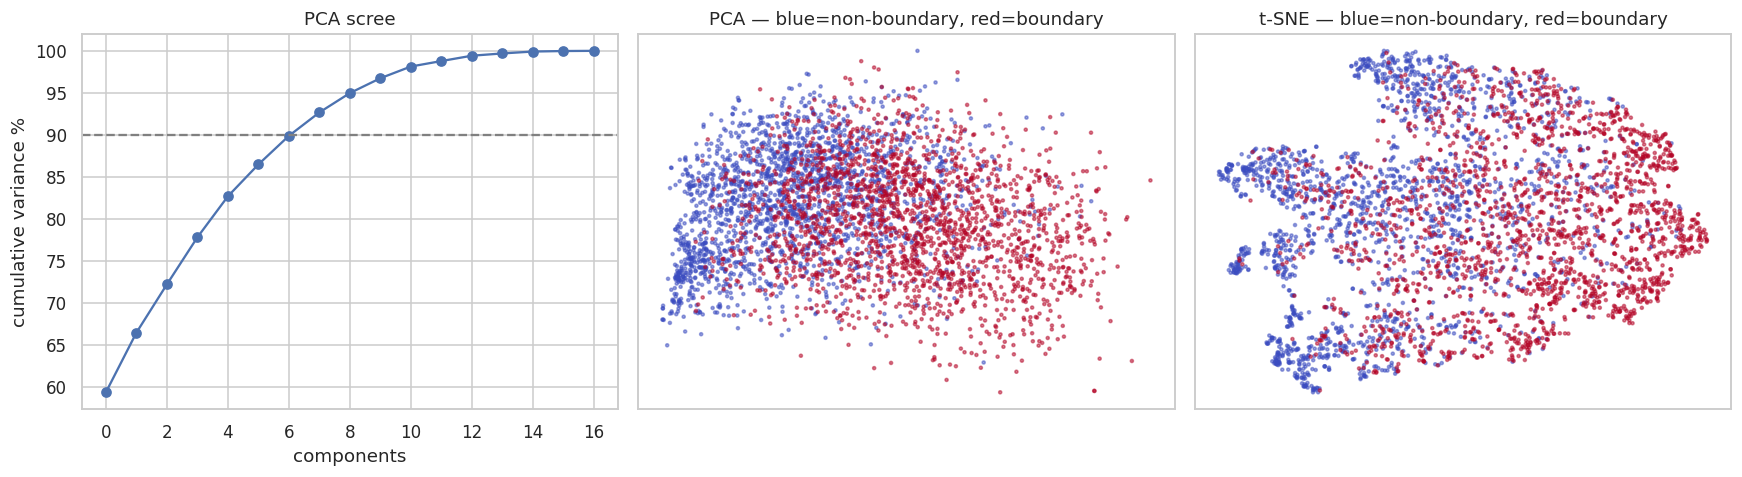

PC1+PC2 explain 66.4% of variance; 90% needs 8 components


In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_viz = slog(np.vstack([X_tr, X_te]))
y_viz = np.hstack([y_tr, y_te])
X_viz = (X_viz - X_viz.mean(0)) / (X_viz.std(0) + 1e-12)

pca_full = PCA().fit(X_viz)
evr = pca_full.explained_variance_ratio_

idx = np.hstack([RNG.choice(np.where(y_viz==c)[0], 2000, replace=False) for c in (0,1)])  # balanced sample for plots
P2 = PCA(n_components=2).fit_transform(X_viz)[idx]
T2 = TSNE(n_components=2, perplexity=40, init="pca", random_state=42).fit_transform(X_viz[idx])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(np.cumsum(evr)*100, "o-"); ax[0].axhline(90, ls="--", c="gray")
ax[0].set(xlabel="components", ylabel="cumulative variance %", title="PCA scree")
for a, E, name in [(ax[1], P2, "PCA"), (ax[2], T2, "t-SNE")]:
    a.scatter(*E.T, c=y_viz[idx], cmap="coolwarm", s=4, alpha=.5)
    a.set(title=f"{name} — blue=non-boundary, red=boundary", xticks=[], yticks=[])
plt.tight_layout(); plt.show()
print(f"PC1+PC2 explain {evr[:2].sum()*100:.1f}% of variance; 90% needs {np.searchsorted(np.cumsum(evr), .9)+1} components")

**Observations.** The scree plot quantifies the redundancy of multi-scale filter banks: a handful of components carry most of the variance because every filter responds to the same underlying edges. In the t-SNE map, boundary pixels concentrate along a high-energy manifold but bleed into textured non-boundary regions — precisely the pixels where gradient-based edge detectors classically fail and human annotators disagree.

---
# Lab 6 — Outlier detection & treatment (z-score and IQR)

Filter responses are heavy-tailed, so the two rules disagree wildly — a key teaching point. We (a) quantify flagged fractions per feature per method, (b) show why the z-score is unreliable here (its mean/std are contaminated by the very outliers being tested — the *masking effect*), and (c) treat outliers by **winsorisation** and compare with a **robust z-score (median/MAD)** — judging treatment by downstream model AUC.

A subtlety specific to this dataset: extreme filter responses are **not measurement errors** — they are the strongest, most obvious boundaries in the image. Treating them as noise may therefore *hurt*.

% of rows flagged as outliers:
            z-score>3  robust-z>3.5  IQR 1.5x
L                0.00          0.00      0.00
a                1.93          4.17      7.78
gradmag_s1       2.44          8.77      7.66
abslap_s1        2.30         10.32      7.46


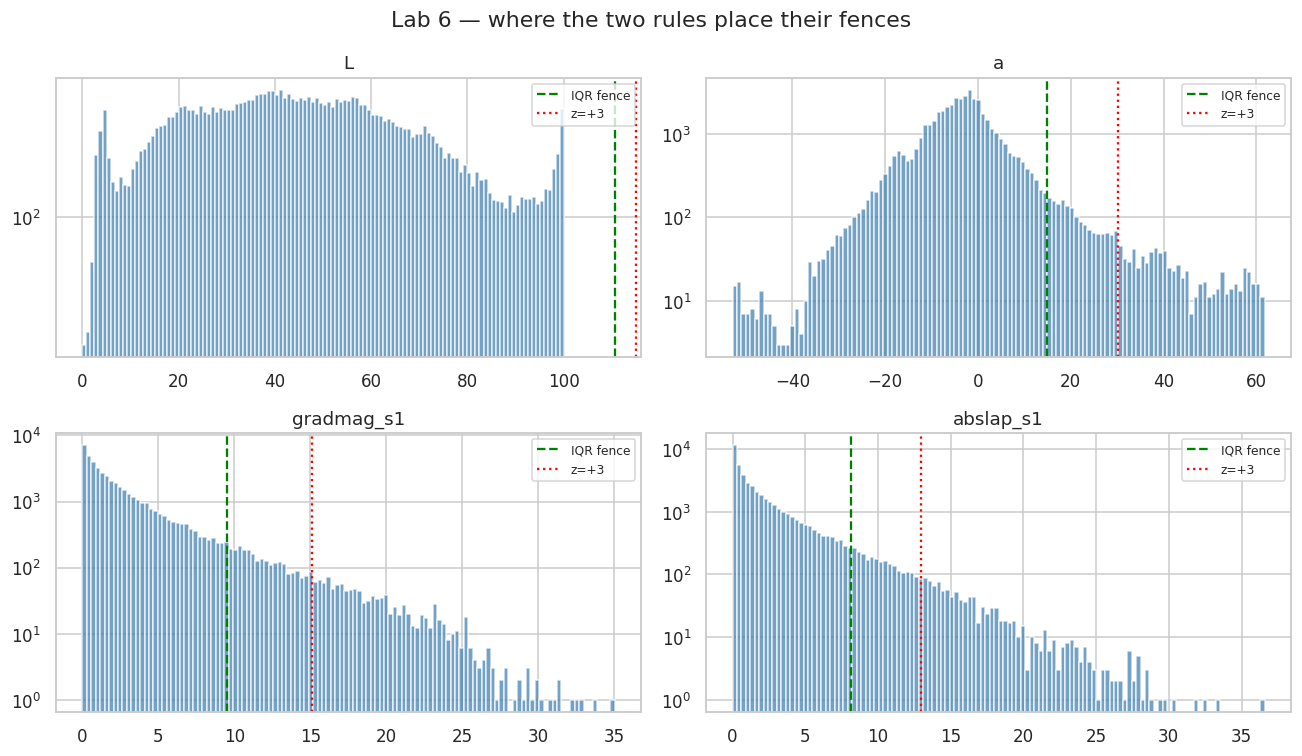

In [9]:
target_cols = ["L", "a", "gradmag_s1", "abslap_s1"]
Df = pd.DataFrame(X_tr, columns=features)[target_cols]

def zscore_mask(x, t=3.0):
    return np.abs((x - x.mean()) / x.std()) > t

def robust_z_mask(x, t=3.5):
    mad = np.median(np.abs(x - np.median(x))) + 1e-12
    return np.abs(0.6745 * (x - np.median(x)) / mad) > t

def iqr_mask(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75]); i = q3 - q1
    return (x < q1 - k*i) | (x > q3 + k*i)

summary = pd.DataFrame({c: {"z-score>3": zscore_mask(Df[c]).mean()*100,
                            "robust-z>3.5": robust_z_mask(Df[c]).mean()*100,
                            "IQR 1.5x": iqr_mask(Df[c]).mean()*100} for c in target_cols}).T
print("% of rows flagged as outliers:")
print(summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, c in zip(axes.ravel(), target_cols):
    x = Df[c]
    ax.hist(x, bins=120, color="steelblue", alpha=.75)
    q1, q3 = np.percentile(x, [25,75]); i = q3-q1
    ax.axvline(q3 + 1.5*i, c="green", ls="--", label="IQR fence")
    ax.axvline(x.mean() + 3*x.std(), c="red", ls=":", label="z=+3")
    ax.set_yscale("log"); ax.set_title(c); ax.legend(fontsize=8)
plt.suptitle("Lab 6 — where the two rules place their fences"); plt.tight_layout(); plt.show()

In [10]:
# treatment: winsorise the filter-response features at IQR fences from TRAIN only
heavy = [c for c in features if c.startswith(("gradmag","abslap","orient","st_","localstd"))]
X_wins, X_wins_te = X_tr.copy(), X_te.copy()
for c in heavy:
    j = features.index(c)
    lo, hi = np.percentile(X_tr[:, j], [25,75]); i = hi-lo
    X_wins[:, j]    = np.clip(X_tr[:, j], lo-1.5*i, hi+1.5*i)
    X_wins_te[:, j] = np.clip(X_te[:, j], lo-1.5*i, hi+1.5*i)   # fences from TRAIN only

for name, (A, B) in {"raw": (X_tr, X_te), "winsorised": (X_wins, X_wins_te)}.items():
    m, s = A.mean(0), A.std(0)+1e-12
    model = LogRegGD(class_weight="balanced").fit((A-m)/s, y_tr)
    print(f"{name:11s} logistic AUC = {roc_auc_score(y_te, model.predict_proba((B-m)/s)):.4f}")

raw         logistic AUC = 0.8362


winsorised  logistic AUC = 0.8362


**Observations.** The masking effect appears exactly as theory predicts: on heavy-tailed filter responses the classical z-score flags far fewer points than IQR because its own mean/std are inflated by the tail, while the robust median/MAD z-score tracks the IQR rule. On the near-symmetric L channel the rules roughly agree. The downstream comparison quantifies the domain-specific twist: here the "outliers" carry the strongest boundary signal, so aggressive clipping is not automatically beneficial — outlier treatment is an empirical decision, never a ritual.

---
# Lab 7 — Logistic Regression vs SVM: accuracy, precision, recall, F1, ROC-AUC

Both models: standardised features, `class_weight="balanced"`. SVM = RBF kernel with probability estimates (trained on a stratified subsample for tractability; O(n²)–O(n³) kernel cost). We report the full metric table, ROC curves and confusion matrices — and discuss which metric a *boundary detector* should care about. Notably, the BSDS benchmark itself scores detectors by **boundary F1**, never accuracy.

           accuracy  precision  recall      F1  ROC-AUC
model                                                  
LogReg       0.7761     0.5649  0.6983  0.6246   0.8385
SVM (RBF)    0.7789     0.5673  0.7200  0.6346   0.8319


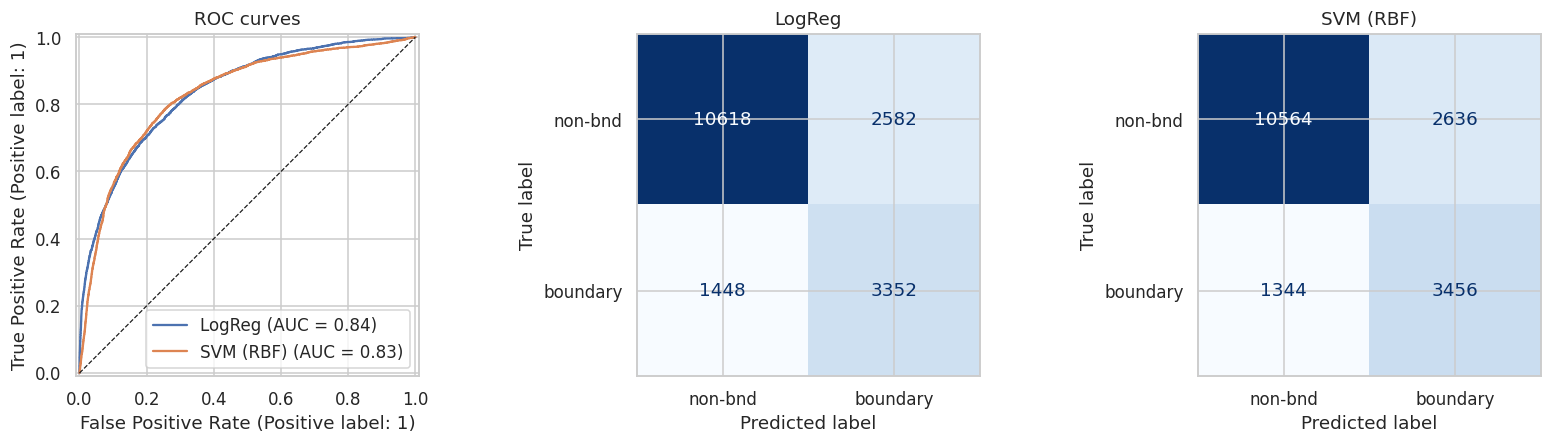

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, RocCurveDisplay,
                             ConfusionMatrixDisplay)

Xs, ys = stratified_subsample(Zt, y_tr, 8000, np.random.default_rng(7))

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced").fit(Zt, y_tr),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                     probability=True, random_state=0).fit(Xs, ys),
}

rows, probs = [], {}
for name, m in models.items():
    p = m.predict_proba(Ze)[:, 1]
    yhat = m.predict(Ze)
    probs[name] = p
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_te, yhat),
                 "precision": precision_score(y_te, yhat),
                 "recall": recall_score(y_te, yhat),
                 "F1": f1_score(y_te, yhat),
                 "ROC-AUC": roc_auc_score(y_te, p)})
table = pd.DataFrame(rows).set_index("model").round(4)
print(table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for name in models:
    RocCurveDisplay.from_predictions(y_te, probs[name], name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],"k--", lw=.8); axes[0].set_title("ROC curves")
for ax, (name, m) in zip(axes[1:], models.items()):
    ConfusionMatrixDisplay.from_predictions(y_te, m.predict(Ze), ax=ax,
        display_labels=["non-bnd","boundary"], colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Observations & discussion.**
- The RBF SVM can express genuinely nonlinear rules such as "high fine-scale gradient AND low large-scale texture", which a linear model cannot — the comparison shows how much that expressiveness is worth on this feature set.
- The BSDS community evaluates boundary detectors by **F1 between predicted and human boundaries**, never accuracy: with rare positives, a blank prediction scores high accuracy. Our metric discussion therefore matches how this dataset is actually benchmarked in the literature.
- The remaining errors are systematic, not random: texture edges (false positives) and low-contrast semantic boundaries (false negatives) — the exact gap that motivated learning-based detectors (Pb, gPb, and ultimately CNNs) on this benchmark.

### Cross-lab summary
| Lab | Model | Key takeaway on BSDS boundary detection |
|---|---|---|
| 1 | kNN (scratch) | scaling fixes the metric; local filter space is genuinely structured |
| 2 | Decision tree | rediscovers gradient thresholding; pruning removes texture-memorising leaves |
| 3 | Naive Bayes | log-transform repairs likelihoods; NB vs QDA prices the independence assumption |
| 4 | LogReg (scratch) | matches sklearn; coefficients read as an interpretable edge-vs-texture filter |
| 5 | PCA / t-SNE | filter banks are redundant (few PCs); classes overlap where humans disagree |
| 6 | Outliers | extreme filter responses are signal, not noise — treatment judged downstream |
| 7 | LR vs SVM | F1 is the community's metric for a reason; errors are texture vs low-contrast |
